In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
df = pd.read_excel(r"C:\Users\ezhil\Downloads\cricket_players_1000.xlsx")



In [5]:
df.head()


,Player,Matches,Runs,StrikeRate,Average,Wickets,Economy
0,Player_1,293,5021,90.22,64.35,283,7.83
1,Player_2,109,2071,146.60,22.36,54,7.31
2,Player_3,106,9536,104.22,35.28,201,3.74
3,Player_4,31,12108,132.85,21.65,212,5.81
4,Player_5,78,6274,158.24,28.79,110,4.67


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      1000 non-null   str    
 1   Matches     1000 non-null   int64  
 2   Runs        1000 non-null   int64  
 3   StrikeRate  1000 non-null   float64
 4   Average     1000 non-null   float64
 5   Wickets     1000 non-null   int64  
 6   Economy     1000 non-null   float64
dtypes: float64(3), int64(3), str(1)
memory usage: 54.8 KB


In [7]:
df.describe()

,Matches,Runs,StrikeRate,Average,Wickets,Economy
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,155.190000,7547.884000,126.213670,34.236230,197.584000,6.778480
std,83.101334,4316.708321,31.937451,17.266716,117.827324,1.915535
min,10.000000,19.000000,70.000000,5.010000,0.000000,3.530000
25%,86.000000,3849.750000,97.860000,19.785000,94.000000,5.080000
50%,158.000000,7765.500000,127.540000,33.105000,196.000000,6.840000
75%,226.000000,11250.250000,154.012500,48.587500,305.000000,8.452500
max,300.000000,14979.000000,179.900000,64.970000,400.000000,10.000000


In [8]:
df.isnull().sum()

Player        0
Matches       0
Runs          0
StrikeRate    0
Average       0
Wickets       0
Economy       0
dtype: int64

In [9]:
X = df[['Matches',
        'Runs',
        'StrikeRate',
        'Average',
        'Wickets',
        'Economy']]

In [10]:
X.head()

,Matches,Runs,StrikeRate,Average,Wickets,Economy
0,293,5021,90.22,64.35,283,7.83
1,109,2071,146.60,22.36,54,7.31
2,106,9536,104.22,35.28,201,3.74
3,31,12108,132.85,21.65,212,5.81
4,78,6274,158.24,28.79,110,4.67


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
X_scaled[:5]

array([[ 1.65916658, -0.58566579, -1.127569  ,  1.74490846,  0.72528797,
         0.54921789],
       [-0.55610554, -1.26939883,  0.6386399 , -0.68815476, -1.21920656,
         0.27761744],
       [-0.59222411,  0.46079342, -0.68899283,  0.06048008,  0.02900608,
        -1.5870241 ],
       [-1.49518829,  1.05691593,  0.20789544, -0.72929491,  0.12240975,
        -0.50584539],
       [-0.92933074, -0.29525308,  1.00328466, -0.31557566, -0.74369698,
        -1.10127714]])

In [14]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

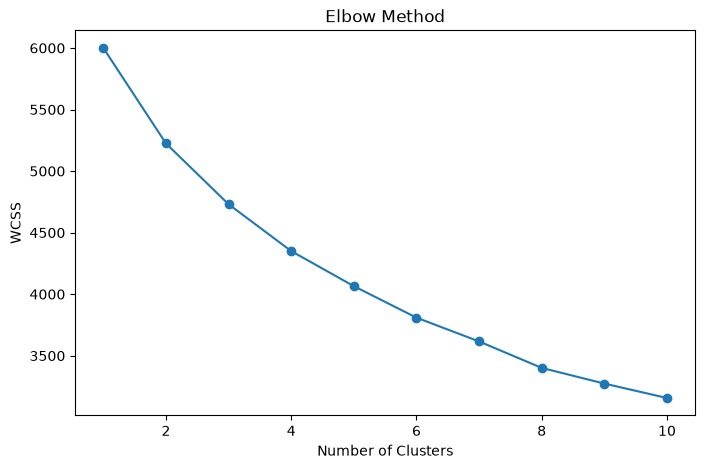

In [15]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [17]:
df['Cluster'] = clusters

df.head()

,Player,Matches,Runs,StrikeRate,Average,Wickets,Economy,Cluster
0,Player_1,293,5021,90.22,64.35,283,7.83,0
1,Player_2,109,2071,146.60,22.36,54,7.31,2
2,Player_3,106,9536,104.22,35.28,201,3.74,1
3,Player_4,31,12108,132.85,21.65,212,5.81,1
4,Player_5,78,6274,158.24,28.79,110,4.67,1


In [18]:
df['Cluster'].value_counts()

Cluster
1    345
2    333
0    322
Name: count, dtype: int64

In [19]:
df.groupby('Cluster').mean(
    numeric_only=True
)

,Matches,Runs,StrikeRate,Average,Wickets,Economy
Cluster,,,,,,
0,216.729814,5719.506211,118.243012,43.555590,245.177019,7.301273
1,125.313043,8384.107246,130.679014,35.634203,186.156522,4.826986
2,126.636637,8449.507508,129.294775,23.776366,163.402402,8.294775


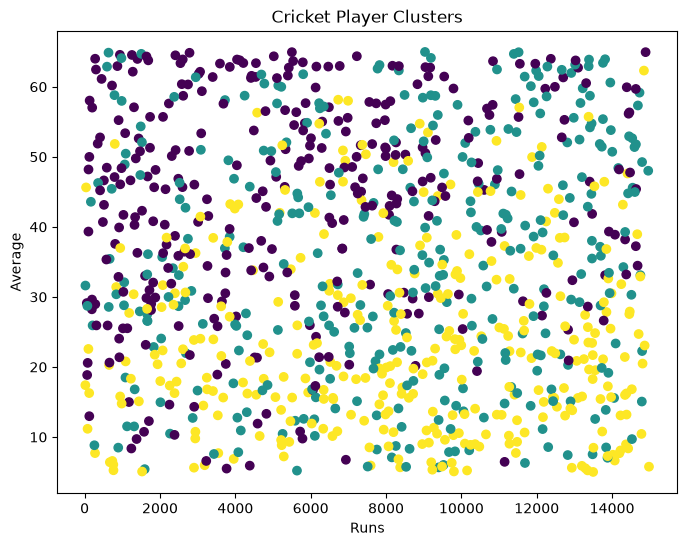

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Runs'],
    df['Average'],
    c=df['Cluster']
)

plt.xlabel("Runs")

plt.ylabel("Average")

plt.title("Cricket Player Clusters")

plt.show()

In [21]:
df.groupby("Cluster").mean(
    numeric_only=True
)

,Matches,Runs,StrikeRate,Average,Wickets,Economy
Cluster,,,,,,
0,216.729814,5719.506211,118.243012,43.555590,245.177019,7.301273
1,125.313043,8384.107246,130.679014,35.634203,186.156522,4.826986
2,126.636637,8449.507508,129.294775,23.776366,163.402402,8.294775


In [22]:
df.groupby("Cluster").mean(
    numeric_only=True
)

,Matches,Runs,StrikeRate,Average,Wickets,Economy
Cluster,,,,,,
0,216.729814,5719.506211,118.243012,43.555590,245.177019,7.301273
1,125.313043,8384.107246,130.679014,35.634203,186.156522,4.826986
2,126.636637,8449.507508,129.294775,23.776366,163.402402,8.294775


In [23]:
import pickle

with open("kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler Saved Successfully")

Scaler Saved Successfully
